# Fine-Tuning a Pre-Trained Model for Mugs Dataset

This notebook implements **fine-tuning** of a pre-trained **Convolutional Neural Network (CNN)** for our own **Mugs** dataset.

## Goals
- Load and preprocess the **Mugs** dataset just like in the previous notebooks
- Use a pre-trained model **(VGG16)** as a base and add custom classification layers on top



In [92]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import matplotlib.pyplot as plt
import numpy as np
import time

from keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [93]:
#tf.config.run_functions_eagerly(True)
#tf.data.experimental.enable_debug_mode()

## Data Preparation

In [94]:
# Load the dataset
img_size = (224, 224)
num_classes = 3
batch_size = 16
seed = 123
data_dir = "/home/valvoja/projects/2026-Spring-Neural-Network-Project/dataset-mug"

common_args = dict(
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    crop_to_aspect_ratio=True
)

train_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    shuffle=True,
    seed=seed,
    **common_args
)

val_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/val",
    shuffle=False,
    **common_args
)

test_ds = keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    shuffle=False,
    **common_args
)

Found 144 files belonging to 3 classes.
Found 33 files belonging to 3 classes.
Found 33 files belonging to 3 classes.


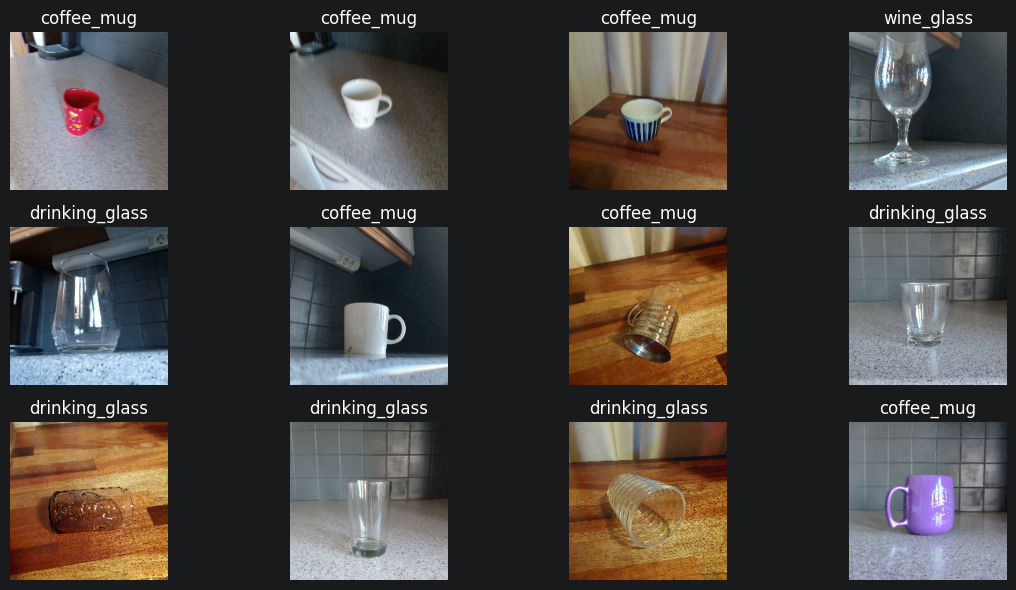

In [95]:
# Show a few sample images from the training set
class_names = train_ds.class_names
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i].numpy())])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Augmentation

To improve generalization, we apply data augmentation to the training images.

In [96]:
augmenter = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
#    layers.RandomZoom(0.08),
#    layers.RandomTranslation(0.05, 0.05)
], name="data_augmentation")

augmenter

<Sequential name=data_augmentation, built=False>

## No Unlocked Layers

## VGG16 as a CNN Base

In [97]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Fine-Tuned CNN Model
This model includes:
- **Data augmentation** layer to apply random horizontal flips and small rotations
- **Preprocessing** layer that uses vgg16 to apply the same preprocessing as what is required for vgg16
- **VGG16** convolutional blocks and layers as the base
- **GlobalAveragePooling** to reduce the spatial dimensions before the dense layers.
- **Dropout** layer with a rate of **0.35** was found to be effective in preventing overfitting.

In [98]:
inputs = keras.Input(shape=(224, 224, 3))

x = augmenter(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="mugs_fine_tuned")

model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

model.summary()

Model: "mugs_fine_tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_19[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_9          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_10         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_11         │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_3 (Stack)     │ (None, 224, 224,  │          0 │ get_item_9[0][0], │
│                     │ 3)                │            │ get_item_10[0][0… │
│                     │                   │            │ get_item_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 224, 224,  │          0 │ stack_3[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 3)         │        771 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Training of the added classification layers

In [99]:
callbacks = [
    ModelCheckpoint(filepath="mugs_fine_tuned.keras", save_best_only=True, monitor="val_loss"),
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

In [100]:
# Training
epochs = 100

start_time = time.time()

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
)

training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - accuracy: 0.5278 - loss: 2.2780 - val_accuracy: 0.8788 - val_loss: 0.7244 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.7014 - loss: 1.4969 - val_accuracy: 0.9394 - val_loss: 0.7008 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.8889 - loss: 0.8588 - val_accuracy: 0.9697 - val_loss: 0.6857 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 205ms/step - accuracy: 0.8889 - loss: 0.7972 - val_accuracy: 1.0000 - val_loss: 0.6491 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.9375 - loss: 0.6480 - val_accuracy: 0.9091 - val_loss: 0.7237 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.8958 - loss: 0.6760 - val_accuracy: 0.9091 - val_loss: 0.6558 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8958 - loss: 0.6666 - val_accu

## Evaluation

Evaluation is done on the best performing model saved during training.

This evaluation step will only include:
- Learning curves for training and validation loss and accuracy
- Evaluation on the test set (loss and accuracy)

In [101]:
best_model = keras.models.load_model("mugs_fine_tuned.keras")

### Learning Curves

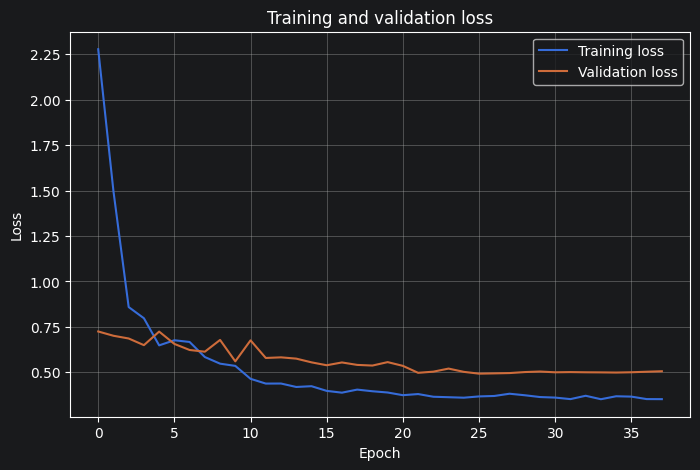

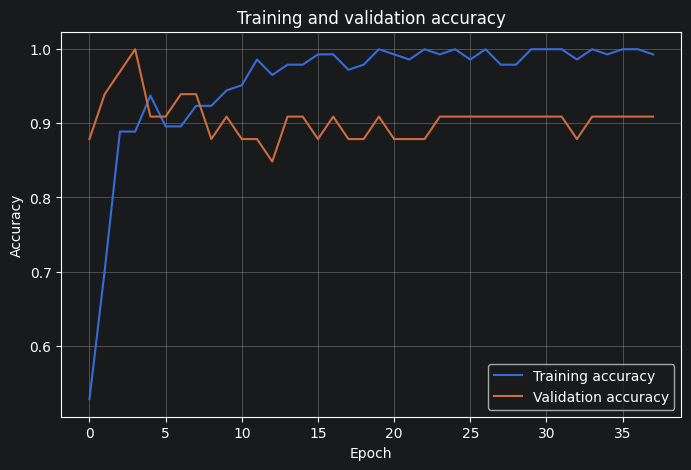

In [102]:
# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on Test Set

In [103]:
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8788 - loss: 0.4866 
Test loss: 0.4866
Test accuracy: 0.8788


## Few Unlocked Layers

In [104]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [105]:
best_model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

history = best_model.fit(
    train_ds,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9931 - loss: 0.3711 - val_accuracy: 0.9091 - val_loss: 0.4932 - learning_rate: 1.0000e-05
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9931 - loss: 0.3723 - val_accuracy: 0.9091 - val_loss: 0.4935 - learning_rate: 1.0000e-05
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9974 - loss: 0.3601
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.9931 - loss: 0.3635 - val_accuracy: 0.9091 - val_loss: 0.4932 - learning_rate: 1.0000e-05
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 1.0000 - loss: 0.3583 - val_accuracy: 0.9091 - val_loss: 0.4935 - learning_rate: 5.0000e-06
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.9861 - loss: 0.3629 - val_accuracy: 0.9091 - val_loss: 0.4943 - learning_rate: 5.0000e-06
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9962 - loss:

## Evaluation of Fine-Tuned Model with Unlocked Layers

In [106]:
best_model = keras.models.load_model("mugs_fine_tuned.keras")

### Learning Curves

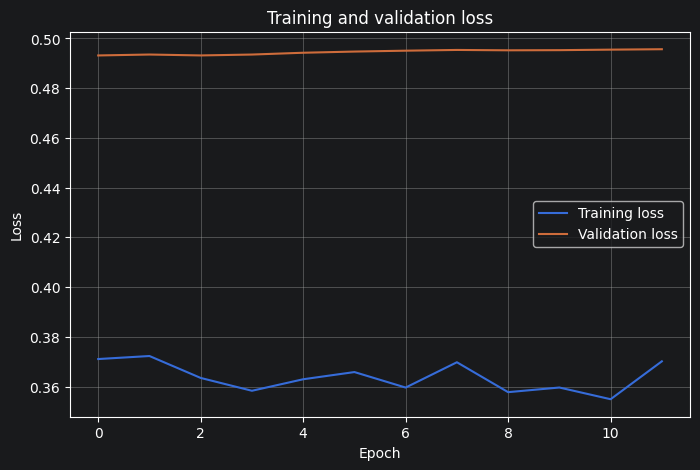

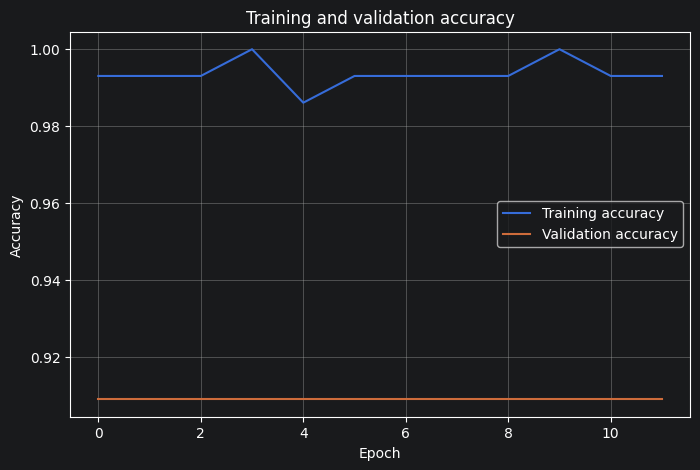

In [107]:
# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on Test Set

The best model is once again evaluated on the test set to see if the unlocked layers have improved performance.

This time we will do the full evaluation:
- Learning curves for training and validation loss and accuracy.
- Test set performance (loss and accuracy).
- Classification report with precision, recall, and F1-score for each class.
- Confusion matrix to visualize the performance across classes.

In [108]:
best_model = keras.models.load_model("mugs_fine_tuned.keras")

In [109]:
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8788 - loss: 0.4866 
Test loss: 0.4866
Test accuracy: 0.8788


### Classification Report

In [110]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_true, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

                precision    recall  f1-score   support

    coffee_mug       1.00      0.75      0.86        12
drinking_glass       0.79      0.92      0.85        12
    wine_glass       0.90      1.00      0.95         9

      accuracy                           0.88        33
     macro avg       0.90      0.89      0.88        33
  weighted avg       0.89      0.88      0.88        33



### Confusion Matrix

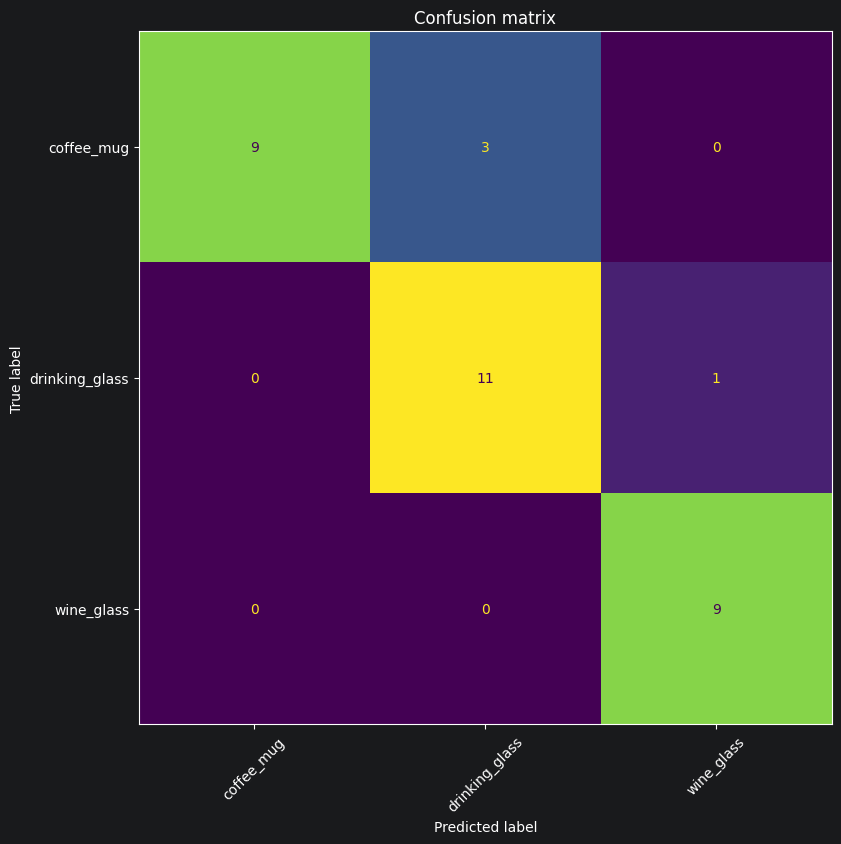

In [111]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion matrix")
plt.show()

## Conclusion

Compared to the **CNN model** trained from scratch and **Feature Extraction model** trained on this same dataset, this **Fine-Tuned model** performs similarly to the **Feature Extraction model** achieving accuracy of around **90%**.

